In [1]:
import pandas as pd
import numpy as np
import re
from google.colab import drive
drive.mount('/content/drive')
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/My Drive/DataScienceLab/merged_data.csv')

# Preprocessing

## 1. Normalizzo
Le variabili sono su scale diversissime, uso metodo MinMax in modo da avere tutto in range [0,1]

*All indicators were normalized using Min–Max scaling to ensure comparability across different measurement scales prior to index construction.*

In [3]:
RAW_COLS = [
    'Employment rate', 'Exposed to air pollution',
       'Households and NPISHs net adjusted disposable income per capita',
       'Housing affordability', 'Job satisfaction', 'Life expectancy at birth',
       'Life satisfaction', 'Satisfaction with personal relationships',
       'Social support', 'Feeling safe at night', 'GDP per capita PPP',
       'Unemployment total percent', 'Life expectancy', 'PM2.5 air pollution',
       'Intentional homicides', 'Household consumption expenditure PPP',
       'Cost of living Index', 'Rent Index', 'Traffic Index', 'Time Index',
       'Inefficiency Index', 'CO2 Emission Index' # Corrected column name
]

scaler = MinMaxScaler()
df[RAW_COLS] = scaler.fit_transform(df[RAW_COLS])

## 2. Feature Engineering

In [4]:
RAW_COLS = [
    # income
    "GDP per capita PPP",
    "Households and NPISHs net adjusted disposable income per capita",
    "Household consumption expenditure PPP",
    # job
    "Employment rate",
    "Unemployment",
    "Unemployment total percent",
    # cost
    "Cost of living Index",
    "Rent Index",
    "Housing affordability",
    # health/env
    "Life expectancy",
    "Life expectancy at birth",
    "PM2.5 air pollution",
    "Exposed to air pollution",
    "CO2 Emission Index",
    # safety
    "Feeling safe at night",
    "Intentional homicides",
    # social
    "Social support",
    "Lack of social support",
    "Job satisfaction",
    "Life satisfaction",
    "Satisfaction with personal relationships",
    # mobility
    "Traffic Index",
    "Time Index",
    "Inefficiency Index"
]

# Solo le colonne effettivamente presenti nel DF
RAW_COLS = [c for c in RAW_COLS if c in df.columns]

# Sostituzioni comuni: '..' e numeri con virgole
df[RAW_COLS] = (
    df[RAW_COLS]
      .replace("..", np.nan)
      .replace(",", "", regex=True)
      .apply(pd.to_numeric, errors="coerce")
)

# ---------------------------
# Orientamento: alto = meglio (inverto le "negative")
# ---------------------------
NEGATIVE_VARS = [
    "Unemployment",
    "Unemployment total percent",
    "Cost of living Index",
    "Rent Index",
    "PM2.5 air pollution",
    "Exposed to air pollution",
    "CO2 Emission Index",
    "Intentional homicides",
    "Lack of social support",
    "Traffic Index",
    "Time Index",
    "Inefficiency Index",
]

for col in NEGATIVE_VARS:
    if col in df.columns:
        df[col] = -df[col]

In [5]:
# funzione media per riga
def row_mean(cols):
    cols = [c for c in cols if c in df.columns]
    return df[cols].mean(axis=1) if cols else np.nan

### Income index
--> capacità economica reale di vivere in una città

```
income_index = mean( GDP_per_capita_PPP, disposable_income_per_capita, consumption_PPP )
```

In [6]:
df["income_index"] = row_mean([
    "GDP per capita PPP",
    "Households and NPISHs net adjusted disposable income per capita",
    "Household consumption expenditure PPP"
])

### Job index
--> facilità di trovare e mantenere lavoro
```
Unemployment_total_percent *= -1

job_index = mean(Employment_rate, Unemployment_total_percent)
```

In [7]:
df["job_index"] = row_mean([
    "Employment rate",
    "Unemployment",
    "Unemployment total percent"
])

### Cost index
--> sostenibilità economica per giovani lavoratori

```
Cost_of_living_Index *= -1
Rent_Index *= -1

cost_index = mean(Cost_of_living_Index, Rent_Index, Housing_affordability)
```

In [8]:
df["cost_index"] = row_mean([
    "Cost of living Index",
    "Rent Index",
    "Housing affordability"
])

### Health environment index

```
PM2_5_air_pollution *= -1
Exposed_to_air_pollution *= -1
CO2_Emission_Index *= -1

health_env_index = mean(Life_expectancy,Life_expectancy_at_birth, PM2_5_air_pollution,
                        Exposed_to_air_pollution, CO2_Emission_Index)
```

In [9]:
df["health_env_index"] = row_mean([
    "Life expectancy",
    "Life expectancy at birth",
    "PM2.5 air pollution",
    "Exposed to air pollution",
    "CO2 Emission Index"
])

### Safety index
```
Intentional_homicides *= -1

safety_index = mean( Feeling_safe_at_night, Intentional_homicides)
```

In [10]:
df["safety_index"] = row_mean([
    "Feeling safe at night",
    "Intentional homicides"
])

### Social index

```

social_index = mean(Social_support, Job_satisfaction, Life_satisfaction,
Satisfaction_with_personal_relationships)
```

In [11]:
df["social_index"] = row_mean([
    "Social support",
    "Job satisfaction",
    "Life satisfaction",
    "Satisfaction with personal relationships"
])

### Mobility index
--> mobilità e accessibilità

```
mobility_index = mean(Traffic_Index, Time_Index, Inefficiency_Index)
```

In [12]:
df["mobility_index"] = row_mean([
    "Traffic Index",
    "Time Index",
    "Inefficiency Index"
])

In [13]:
INDEX_COLS = [
    "income_index",
    "job_index",
    "cost_index",
    "health_env_index",
    "safety_index",
    "social_index",
    "mobility_index"
]

In [14]:
# Dataset finale per modellazione
df_indices = df[["Country", "Year"] + INDEX_COLS].copy()
df_indices

,Country,Year,income_index,job_index,cost_index,health_env_index,safety_index,social_index,mobility_index
0,Albania,2018,0.013117,-0.599452,-0.071387,0.021572,-0.413433,NaN,NaN
1,Albania,2019,0.018459,-0.550629,-0.070926,0.089227,-0.407783,NaN,NaN
2,Albania,2020,0.017645,-0.563680,-0.074385,0.038034,-0.381152,NaN,NaN
3,Albania,2021,0.024906,-0.551095,-0.098165,0.406725,-0.420798,NaN,NaN
4,Albania,2022,0.039699,-0.473200,-0.070144,0.526588,-0.293138,NaN,NaN
...,...,...,...,...,...,...,...,...,...
331,United Kingdom,2020,0.472423,0.259348,-0.141385,-0.135051,0.167121,0.573911,-0.516452
332,United Kingdom,2021,0.518785,0.242798,-0.162299,0.183282,0.149278,0.603700,-0.504586
333,United Kingdom,2022,0.568667,0.284018,-0.170355,0.199441,0.472222,0.585827,-0.503103
334,United Kingdom,2023,0.584577,0.281243,-0.116734,0.206187,0.537037,0.461184,-0.513907


## 2. Missing Values
*Missing values in the composite indices were handled using a two-step approach: first, country-level temporal interpolation was applied to exploit the panel structure of the data; second, remaining gaps were filled using global mean imputation. Indices with excessive missingness were excluded from the modeling stage.*

In [15]:
# Check missing sugli indici
df_indices.isna().sum().sort_values(ascending=False)

,0
social_index,164
mobility_index,91
safety_index,90
job_index,88
income_index,73
cost_index,48
health_env_index,42
Country,0
Year,0


- social_index	~49%
- health_env_index	~29%
- mobility_index ~27%
- safety_index	~27%
- job_index	~26%
- income_index	~22%
- cost_index	~14%


STEP 1 — Interpolazione temporale per Country

In [16]:
df_indices = df_indices.sort_values(["Country", "Year"])

df_indices[INDEX_COLS] = (
    df_indices
      .groupby("Country")[INDEX_COLS]
      .transform(lambda g: g.interpolate(method="linear", limit_direction="both"))
)

STEP 2 — Media globale

In [17]:
df_indices[INDEX_COLS] = (
    df_indices[INDEX_COLS]
      .fillna(df_indices[INDEX_COLS].mean())
)

In [18]:
df_indices[INDEX_COLS].isna().sum()

,0
income_index,0
job_index,0
cost_index,0
health_env_index,0
safety_index,0
social_index,0
mobility_index,0


In [19]:
df_indices

,Country,Year,income_index,job_index,cost_index,health_env_index,safety_index,social_index,mobility_index
0,Albania,2018,0.013117,-0.599452,-0.071387,0.021572,-0.413433,0.632182,-0.375541
1,Albania,2019,0.018459,-0.550629,-0.070926,0.089227,-0.407783,0.632182,-0.375541
2,Albania,2020,0.017645,-0.563680,-0.074385,0.038034,-0.381152,0.632182,-0.375541
3,Albania,2021,0.024906,-0.551095,-0.098165,0.406725,-0.420798,0.632182,-0.375541
4,Albania,2022,0.039699,-0.473200,-0.070144,0.526588,-0.293138,0.632182,-0.375541
...,...,...,...,...,...,...,...,...,...
331,United Kingdom,2020,0.472423,0.259348,-0.141385,-0.135051,0.167121,0.573911,-0.516452
332,United Kingdom,2021,0.518785,0.242798,-0.162299,0.183282,0.149278,0.603700,-0.504586
333,United Kingdom,2022,0.568667,0.284018,-0.170355,0.199441,0.472222,0.585827,-0.503103
334,United Kingdom,2023,0.584577,0.281243,-0.116734,0.206187,0.537037,0.461184,-0.513907


In [20]:
df_indices.describe().loc[["min", "max"]]

,Year,income_index,job_index,cost_index,health_env_index,safety_index,social_index,mobility_index
min,2018.0,0.013117,-1.000000,-0.902110,-0.945542,-1.000000,0.011136,-0.948967
max,2024.0,1.000000,0.751368,0.224766,1.000000,0.967593,1.000000,-0.055609


In [21]:
df[INDEX_COLS].var().sort_values(ascending=False)

,0
health_env_index,0.158759
job_index,0.114008
safety_index,0.110961
cost_index,0.046853
social_index,0.034603
income_index,0.032816
mobility_index,0.027578


In [22]:
# Ri-normalizzo
scaler = MinMaxScaler()
df[INDEX_COLS] = scaler.fit_transform(df[INDEX_COLS])

### utile

*After imputing missing values, composite indices exhibited heterogeneous ranges and variances; therefore, Min–Max normalization was reapplied to ensure equal contribution across features in distance-based analyses.*

# Trend

Per evitare di basare le raccomandazioni solo su una fotografia statica delle città, abbiamo costruito un secondo dataset che cattura la dinamica temporale degli indicatori principali, sintetizzando per ogni paese un indice di trend calcolato sui dati storici.

In [23]:
def slope_linear(years: pd.Series, values: pd.Series) -> float:
    tmp = pd.DataFrame({"Year": years, "Value": values}).dropna()
    if len(tmp) < 2:
        return np.nan
    # polyfit: Value = a + b*Year  -> b è il trend
    b = np.polyfit(tmp["Year"].astype(float), tmp["Value"].astype(float), 1)[0]
    return float(b)

In [24]:
# DF dei trend
df_trends = (
    df_indices.groupby("Country", as_index=False)
      .apply(lambda g: pd.Series({f"trend_{c}": slope_linear(g["Year"], g[c]) for c in INDEX_COLS}))
      .reset_index(drop=True)
)

/tmp/ipython-input-1433911779.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({f"trend_{c}": slope_linear(g["Year"], g[c]) for c in INDEX_COLS}))


In [25]:
df_trends

,Country,trend_income_index,trend_job_index,trend_cost_index,trend_health_env_index,trend_safety_index,trend_social_index,trend_mobility_index
0,Albania,7.648182e-03,2.170448e-02,-4.862682e-03,4.608874e-02,3.566331e-02,-1.101355e-18,1.198256e-17
1,Andorra,2.683450e-02,-9.318152e-19,-1.681440e-18,1.136165e-01,3.132270e-17,-1.101355e-18,-2.585376e-18
2,Austria,2.856454e-02,4.002897e-02,1.618166e-02,2.358156e-02,4.380117e-02,1.857012e-02,5.470036e-03
3,Azerbaijan,7.826271e-03,-3.670473e-03,-1.681440e-18,1.072588e-01,-9.085494e-03,-1.101355e-18,-2.585376e-18
4,Belarus,-1.308909e-18,-9.318152e-19,5.766728e-03,5.221690e-02,-3.694706e-18,-1.101355e-18,1.496824e-03
5,Belgium,3.066585e-02,4.435801e-02,1.907547e-02,-5.899891e-02,2.645503e-02,2.769834e-02,-1.843604e-02
6,Bosnia and Herzegovina,5.740203e-03,7.551104e-02,3.796093e-03,2.178120e-02,3.984993e-04,-1.101355e-18,-1.189791e-02
7,Bulgaria,1.430302e-02,5.565616e-02,-1.228534e-02,1.363972e-02,5.498342e-03,-6.983452e-02,6.953063e-03
8,Croatia,1.522567e-02,6.975728e-02,5.597335e-03,1.373214e-02,3.263117e-02,5.789643e-02,1.484964e-02
9,Czechia,2.836359e-02,5.207677e-02,2.054128e-02,3.599480e-02,3.230499e-02,-7.828155e-03,5.581042e-03


In [26]:
# DF ultimo anno disponibile per ogni Country (2024)
df_levels_latest = (
    df_indices.sort_values(["Country", "Year"])
      .groupby("Country", as_index=False)
      .tail(1)[["Country", "Year"] + INDEX_COLS]
      .rename(columns={"Year": "latest_year"})
      .reset_index(drop=True)
)

In [27]:
df_levels_latest

,Country,latest_year,income_index,job_index,cost_index,health_env_index,safety_index,social_index,mobility_index
0,Albania,2024,0.057612,-0.479783,-0.109382,-0.037270,-0.229061,0.632182,-0.375541
1,Andorra,2024,0.450839,0.026283,-0.152370,0.854857,-0.476227,0.632182,-0.330615
2,Austria,2024,0.426863,0.200524,-0.345163,-0.065201,0.731481,0.666697,-0.069913
3,Azerbaijan,2024,0.068868,-0.208518,-0.152370,0.256351,-0.388837,0.632182,-0.330615
4,Belarus,2024,0.265963,0.026283,-0.028042,-0.594533,0.100388,0.632182,-0.276772
5,Belgium,2024,0.431308,0.148776,-0.307960,-0.945542,0.398148,0.677058,-0.590407
6,Bosnia and Herzegovina,2024,0.045468,-0.507341,-0.042884,-0.366615,-0.195498,0.632182,-0.189353
7,Bulgaria,2024,0.131495,0.284324,-0.096969,-0.425937,-0.167521,0.486381,-0.222686
8,Croatia,2024,0.148180,0.169779,-0.174203,-0.445452,0.467593,0.585671,-0.174090
9,Czechia,2024,0.370379,0.440850,-0.054947,-0.138339,0.523148,0.715427,-0.155355


In [28]:
# Normalizzo nuovamente
scaler_levels = MinMaxScaler()
df_levels_latest[INDEX_COLS] = scaler_levels.fit_transform(
    df_levels_latest[INDEX_COLS]
)

trend_cols = [f"trend_{c}" for c in INDEX_COLS]

scaler_trends = MinMaxScaler()
df_trends[trend_cols] = scaler_trends.fit_transform(
    df_trends[trend_cols]
)

In [29]:
df_trends.head()

,Country,trend_income_index,trend_job_index,trend_cost_index,trend_health_env_index,trend_safety_index,trend_social_index,trend_mobility_index
0,Albania,0.128742,0.250360,0.201991,0.595940,0.650147,0.419600,0.416705
1,Andorra,0.390584,0.098307,0.261978,0.908556,0.492254,0.419600,0.416705
2,Austria,0.414195,0.378734,0.461599,0.491744,0.686175,0.531178,0.479410
3,Azerbaijan,0.131172,0.072593,0.261978,0.879124,0.452029,0.419600,0.416705
4,Belarus,0.024364,0.098307,0.333118,0.624310,0.492254,0.419600,0.433863


In [30]:
df_levels_latest.head()

,Country,latest_year,income_index,job_index,cost_index,health_env_index,safety_index,social_index,mobility_index
0,Albania,2024,0.012722,0.154114,0.751520,0.466848,0.391818,0.512635,0.551521
1,Andorra,2024,0.424680,0.501816,0.704960,0.925397,0.266200,0.512635,0.615603
2,Austria,2024,0.399562,0.621532,0.496145,0.452492,0.880000,0.558368,0.987472
3,Azerbaijan,2024,0.024515,0.340492,0.704960,0.617768,0.310614,0.512635,0.615603
4,Belarus,2024,0.230998,0.501816,0.839620,0.180417,0.559256,0.512635,0.692405


# Clustering e Recommendation System

I trend catturano la dinamica temporale degli indicatori, ma non rappresentano caratteristiche strutturali dei paesi. Per questo motivo il clustering è stato effettuato sugli indicatori di livello, mentre i trend sono stati integrati successivamente nel sistema di raccomandazione.

I trend servono a descrivere COME si muovono i paesi dentro ogni cluster -> profilo di crescita

Integrare tre livelli di informazione nel ranking finale:
- similarità strutturale (livelli)
- similarità dinamica (trend)
- performance dinamica relativa al cluster

-> premi per i paesi che stanno crescendo meglio dei “pari”.

*Il punteggio finale integra la similarità rispetto alle preferenze dell’utente con un termine correttivo basato sulla performance dinamica relativa al cluster di appartenenza, premiando i paesi che mostrano traiettorie di crescita migliori rispetto ai propri pari strutturali.*

- Step 1 — Clustering dei paesi

I paesi vengono raggruppati usando K-Means sui Current Levels: income, employment, cost of living, health & environment, safety, social life, mobility.

Il numero ottimale di cluster viene scelto tramite Silhouette Score, così da massimizzare la coesione interna E mantenere una buona separazione tra cluster.

Ogni cluster rappresenta paesi con livelli socio-economici comparabili.

- Step 2 — Similarità pesata sui livelli attuali

Le preferenze dell’utente sono trasformate in un vettore di pesi normalizzato.

La similarità tra utente e paese viene calcolata tramite Cosine Similarity, dando maggiore importanza agli indicatori che l’utente considera più rilevanti.

Questo produce un primo punteggio: `sim_levels`

- Step 3 — Similarità pesata sui trend di crescita

Lo stesso approccio viene applicato ai Growth Trends: variazioni nel tempo degli stessi indicatori

Si ottiene un secondo punteggio: `sim_trends`

- Step 4 — Bonus cluster-aware sui trend

Per ogni paese si calcola il trend medio del cluster di appartenenza e si misura quanto il paese si discosta da questa media.

```
relative_trend = trend_country − mean_trend_cluster
```

- Step 5 — Score finale

Il punteggio finale è una combinazione pesata:

```
Final Score=0.6⋅sim_levels+0.3⋅sim_trends+0.1⋅relative_trend_norm
```

Questa scelta riflette: priorità ai livelli attuali, importanza significativa alla direzione futura e ruolo correttivo del contesto cluster

1. CLUSTERING (KMeans) sui livelli

In [31]:
def choose_k_by_silhouette(X: np.ndarray, k_min=2, k_max=8, random_state=42):
    best_k, best_score = None, -1
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        if score > best_score:
            best_score, best_k = score, k
    return best_k, best_score

In [32]:
def fit_kmeans_clusters(
    df_levels_latest: pd.DataFrame,
    level_cols=INDEX_COLS,
    k: int | None = None,
    random_state=42
):
    """
    Input: df_levels_latest, con colonne ["Country"] + level_cols
    Output:
      - df_levels_with_cluster: df_levels_latest + colonna "cluster"
      - kmeans_model
      - cluster_profile (medie per cluster)
    """
    X = df_levels_latest[level_cols].values

    if k is None:
        k, sil = choose_k_by_silhouette(X, k_min=2, k_max=8, random_state=random_state)
        print(f"[Clustering] Scelto k={k} con silhouette={sil:.3f}")

    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    df_levels_with_cluster = df_levels_latest.copy()
    df_levels_with_cluster["cluster"] = kmeans.fit_predict(X)

    cluster_profile = (
        df_levels_with_cluster
        .groupby("cluster")[level_cols]
        .mean()
        .round(3)
        .sort_index()
    )

    return df_levels_with_cluster, kmeans, cluster_profile

2. Cluster-aware recommendation

IDEA BASE: Non tutti i paesi devono essere confrontati allo stesso modo.
Paesi con livelli socio-economici simili appartengono a “famiglie” comparabili (cluster).
All’interno di ogni cluster, però, alcuni paesi stanno migliorando più velocemente di altri.

Un sistema di raccomandazione classico considera solo: livelli attuali (quanto un paese è “buono oggi”).

Un sistema cluster-aware considera anche: dinamiche di crescita relative, confrontate con paesi simili, non con tutti.



In [33]:
def build_user_vector(preferences: dict, cols: list[str]) -> np.ndarray:
    missing = [c for c in cols if c not in preferences]
    if missing:
        raise ValueError(f"Mancano preferenze per: {missing}")
    return np.array([preferences[c] for c in cols], dtype=float)

In [34]:
def normalize_user_weights(vec: np.ndarray) -> np.ndarray:
    s = vec.sum()
    if s == 0:
        return np.ones_like(vec) / len(vec)
    return vec / s

In [35]:
def cluster_aware_ranking(
    df_levels_with_cluster: pd.DataFrame,
    df_trends: pd.DataFrame,
    user_prefs_levels: dict,
    user_prefs_trends: dict | None = None,
    level_cols=INDEX_COLS,
    trend_cols=trend_cols,
    w_levels=0.6,
    w_trends=0.3,
    w_cluster=0.1
):
    """
    Input:
      - df_levels_with_cluster: Country + level_cols + cluster (levels già scalati)
      - df_trends: Country + trend_cols (trends già scalati)
      - user_prefs_levels: pesi utente (1-5 o 0-1) con chiavi = level_cols
      - user_prefs_trends:
          * None -> usa stessi pesi dei levels
          * dict con chiavi = trend_cols (oppure chiavi = level_cols, verranno mappate in trend_)
    Output:
      - df_rank ordinato per final_score
    """

    # Allinea per Country
    df_merged = (
        df_levels_with_cluster[["Country", "cluster"] + level_cols]
        .merge(df_trends[["Country"] + trend_cols], on="Country", how="inner")
        .copy()
    )

    # Pesi utente (normalizzati a somma=1)
    user_w_levels = normalize_user_weights(build_user_vector(user_prefs_levels, level_cols))

    if user_prefs_trends is None:
        user_w_trends = user_w_levels.copy()
    else:
        # A) già con chiavi trend_*
        if all(k in user_prefs_trends for k in trend_cols):
            user_w_trends = normalize_user_weights(build_user_vector(user_prefs_trends, trend_cols))
        else:
            # B) chiavi come level_cols -> mappa su trend_
            mapped = {f"trend_{k}": v for k, v in user_prefs_trends.items()}
            user_w_trends = normalize_user_weights(build_user_vector(mapped, trend_cols))

    # Weighted cosine similarity
    X_levels = df_merged[level_cols].values * user_w_levels
    X_trends = df_merged[trend_cols].values * user_w_trends

    # "Direzione" utente: pesi come vettore (metodo semplice e spiegabile)
    u_levels = np.ones((1, len(level_cols))) * user_w_levels
    u_trends = np.ones((1, len(trend_cols))) * user_w_trends

    df_merged["sim_levels"] = cosine_similarity(u_levels, X_levels).flatten()
    df_merged["sim_trends"] = cosine_similarity(u_trends, X_trends).flatten()

    # Cluster-aware bonus: crescita relativa al cluster
    df_merged["trend_score"] = df_merged[trend_cols].mean(axis=1)
    df_merged["cluster_trend_mean"] = df_merged.groupby("cluster")["trend_score"].transform("mean")
    df_merged["relative_trend"] = df_merged["trend_score"] - df_merged["cluster_trend_mean"]

    # Normalizza relative_trend in [-1, 1] per renderlo comparabile (bonus/malus)
    rel_scaler = MinMaxScaler(feature_range=(-1, 1))
    df_merged["relative_trend_norm"] = rel_scaler.fit_transform(df_merged[["relative_trend"]])

    # Score finale
    df_merged["final_score"] = (
        w_levels * df_merged["sim_levels"] +
        w_trends * df_merged["sim_trends"] +
        w_cluster * df_merged["relative_trend_norm"]
    )

    df_rank = df_merged.sort_values("final_score", ascending=False).reset_index(drop=True)
    return df_rank

In [36]:
# Clustering su df_levels_latest
df_levels_with_cluster, kmeans_model, cluster_profile = fit_kmeans_clusters(
    df_levels_latest, level_cols=INDEX_COLS, k=None, random_state=42
)


[Clustering] Scelto k=4 con silhouette=0.252


ESEMPIO

In [37]:
# Esempio preferenze utente
user_prefs_levels = {
    "income_index": 5,
    "job_index": 4,
    "cost_index": 2,
    "health_env_index": 4,
    "safety_index": 3,
    "social_index": 2,
    "mobility_index": 1,
}

In [38]:
# None, se non vuoi distinguere trend
user_prefs_trends = None

# 3.3 Ranking cluster-aware
df_ranking = cluster_aware_ranking(
    df_levels_with_cluster=df_levels_with_cluster,
    df_trends=df_trends,
    user_prefs_levels=user_prefs_levels,
    user_prefs_trends=user_prefs_trends,
    level_cols=INDEX_COLS,
    trend_cols=trend_cols,
    w_levels=0.6,
    w_trends=0.3,
    w_cluster=0.1
)

In [39]:
print(
    "\n[Top 10 - Cluster-aware recommendation]\n",
    df_ranking[["Country", "cluster", "final_score", "sim_levels", "sim_trends", "relative_trend_norm"]].head(10)
)


[Top 10 - Cluster-aware recommendation]
        Country  cluster  final_score  sim_levels  sim_trends  \
0  Netherlands        1     0.975533    0.971546    0.975351   
1      Finland        1     0.910191    0.956435    0.962069   
2      Denmark        1     0.880242    0.969621    0.972236   
3    Lithuania        1     0.871168    0.923805    0.957395   
4      Hungary        2     0.855480    0.882335    0.963476   
5        Italy        2     0.852435    0.908171    0.938602   
6      Andorra        3     0.851882    0.930761    0.852825   
7   Luxembourg        1     0.848398    0.894425    0.859867   
8       Sweden        1     0.839469    0.966472    0.976641   
9       Poland        2     0.831601    0.871240    0.924452   

   relative_trend_norm  
0             1.000000  
1             0.477092  
2             0.067980  
3             0.296663  
4             0.370361  
5             0.259514  
6             0.375773  
7             0.537835  
8            -0.334065  
9  

# PCA

La PCA è utilizzata esclusivamente a scopo esplorativo e non come criterio di validazione del clustering.

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df_levels_with_cluster[INDEX_COLS].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = df_levels_with_cluster.copy()
df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]

print("Varianza spiegata:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Totale: {pca.explained_variance_ratio_.sum():.2%}")

Varianza spiegata:
PC1: 39.52%
PC2: 24.17%
Totale: 63.69%


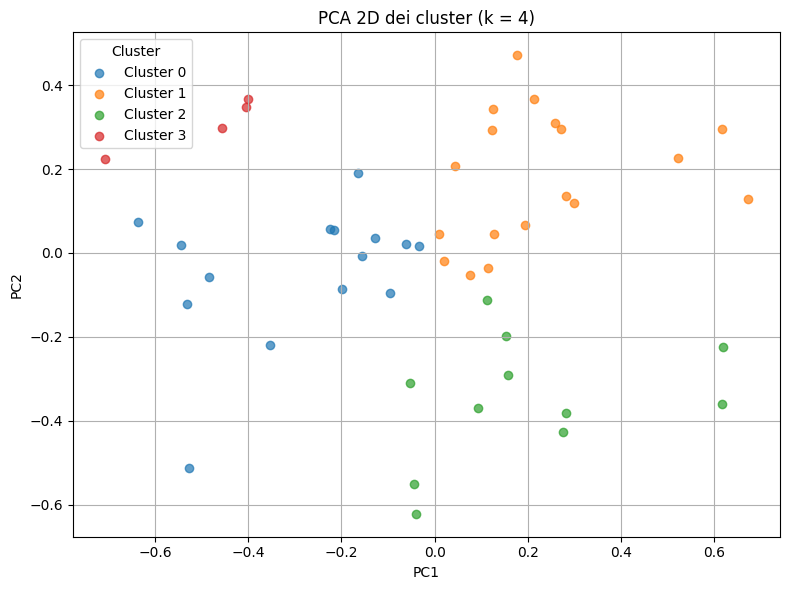

In [41]:
plt.figure(figsize=(8, 6))

for cid in sorted(df_pca["cluster"].unique()):
    subset = df_pca[df_pca["cluster"] == cid]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cid}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D dei cluster (k = 4)")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

*La rappresentazione PCA in due dimensioni mostra una parziale separazione tra i cluster, con alcune aree di sovrapposizione, coerente con la natura continua degli indicatori socio-economici utilizzati. La prima componente principale (PC1) sembra catturare una dimensione di benessere socio-economico complessivo, mentre la seconda (PC2) evidenzia differenze legate a specifici aspetti della qualità della vita e dei servizi. Alcuni cluster risultano più compatti, suggerendo profili strutturali ben definiti, mentre altri mostrano una maggiore dispersione, indicando transizioni graduali tra tipologie di città.*

In [42]:
path = "/content/drive/MyDrive/DataScienceLab/df_levels_latest.csv"
df_levels_latest.to_csv(path, index=False)

In [43]:
path = "/content/drive/MyDrive/DataScienceLab/df_trends.csv"
df_trends.to_csv(path, index=False)